# Cuff-less Blood Pressure Data Preprocessing

This notebook preprocesses the UCI Cuff-less Blood Pressure dataset for blood pressure estimation using PPG signals.

The preprocessing steps include loading the MATLAB v7.3 data, separating PPG and ABP signals, checking for invalid values, creating 5-second windows, extracting systolic and diastolic blood pressure labels, checking for potential outliers, and normalizing the PPG signals.

In [7]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from pathlib import Path
import mat73 

## Load the Dataset

The dataset is stored as a MATLAB v7.3 file and is loaded using `mat73`. Part 1 of the dataset contains 3,000 physiological signal records.

## Preprocess All Records

Each record contains PPG and ABP signals sampled at 125 Hz. The signals are divided into 5-second windows, giving 625 samples per window.

For each window, peaks and valleys in the ABP signal are used to estimate systolic and diastolic blood pressure. The corresponding PPG window is normalized using z-score normalization. Windows with invalid data, missing peaks or valleys, or flat PPG signals are skipped.

In [8]:

#returns all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels
def check_part(part_number, wantResult = True, removePrint = False):
    # Keep moving upward until we find the real dataset, should be in the data folder but if for some reason we are somewhere else should still be able to find it
    ROOT = Path.cwd()

    while ROOT != ROOT.parent and not (ROOT / "data" / "Part_1.mat").exists():
        ROOT = ROOT.parent

    DATA_DIR = ROOT / "data"
    
    # Builds the file name depending on which part we are checking
    file_path = DATA_DIR / f"Part_{part_number}.mat"
    key = f"Part_{part_number}"

    if not removePrint:
        print("\n" + "=" * 60)
        print(f"CHECKING PART {part_number}")
        print("=" * 60)

    if not file_path.exists():
        print(f"Part_{part_number}.mat was NOT found.")
        return

    if not removePrint:
        print(f"Loading Part_{part_number}...")

    data = mat73.loadmat(file_path)
    records = data[key]

    if not removePrint:
        print("Loaded!")
        print("Number of records:", len(records))

    all_ppg_windows = []
    all_abp_windows = []
    all_systolic_labels = []
    all_diastolic_labels = []

    window_size = 625

    invalid_records = 0
    flat_ppg_windows = 0
    no_peak_windows = 0

    for i in range(len(records)):

        record = np.asarray(records[i])

        ppg = record[0]
        abp = record[1]

        # Skip records with invalid values
        if not np.all(np.isfinite(ppg)) or not np.all(np.isfinite(abp)):
            invalid_records += 1
            continue

        # Create 5-second windows 
        #Note, changed this for loop to help with speed hopefully it works, if not can change back to the original for loop
        num_windows = len(ppg) // window_size
        ppg_windows = ppg[:num_windows * window_size].reshape(num_windows, window_size)
        abp_windows = abp[:num_windows * window_size].reshape(num_windows, window_size)

        # Calculate mean/std for every PPG window at once (hopefully this is faster)
        ppg_means = np.mean(ppg_windows, axis=1)
        ppg_stds = np.std(ppg_windows, axis=1)

        for j in range(num_windows):

            if ppg_stds[j] == 0:
                flat_ppg_windows += 1
                continue

            ppg_window = ppg_windows[j]
            abp_window = abp_windows[j]

            peaks, _ = find_peaks(abp_window, distance=50)
            valleys, _ = find_peaks(-abp_window, distance=50)

            if len(peaks) == 0 or len(valleys) == 0:
                no_peak_windows += 1
                continue

            systolic = np.median(abp_window[peaks])
            diastolic = np.median(abp_window[valleys])

            normalized_ppg = (
                ppg_window - ppg_means[j]
            ) / ppg_stds[j]

            all_ppg_windows.append(normalized_ppg)
            all_abp_windows.append(abp_window)
            all_systolic_labels.append(systolic)
            all_diastolic_labels.append(diastolic)

            
    

    #Used for analysis later
    all_ppg_windows = np.array(all_ppg_windows)
    all_abp_windows = np.array(all_abp_windows)
    all_systolic_labels = np.array(all_systolic_labels)
    all_diastolic_labels = np.array(all_diastolic_labels)

    if(wantResult or not removePrint):
        #Results:
        print("Records processed:", len(records))
        print("Invalid records skipped:", invalid_records)
        print("Flat PPG windows skipped:", flat_ppg_windows)
        print("Windows without peaks/valleys:", no_peak_windows)

        print("\nTotal valid examples:", len(all_ppg_windows))

        print("PPG dataset shape:", all_ppg_windows.shape)
        print("ABP dataset shape:", all_abp_windows.shape)
        print("Systolic labels shape:", all_systolic_labels.shape)
        print("Diastolic labels shape:", all_diastolic_labels.shape)

    #Returns the windows for later analysis
    return tuple([all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels])
    


In [9]:
#Storing them so the preprocessing doesn't have to be done again and again, can just load the results from this variable
#This was the best way to make it faster
part1 = check_part(1)
part2 = check_part(2)
part3 = check_part(3)
part4 = check_part(4)


CHECKING PART 1
Loading Part_1...
Loaded!
Number of records: 3000
Records processed: 3000
Invalid records skipped: 0
Flat PPG windows skipped: 0
Windows without peaks/valleys: 1

Total valid examples: 131162
PPG dataset shape: (131162, 625)
ABP dataset shape: (131162, 625)
Systolic labels shape: (131162,)
Diastolic labels shape: (131162,)

CHECKING PART 2
Loading Part_2...
Loaded!
Number of records: 3000
Records processed: 3000
Invalid records skipped: 0
Flat PPG windows skipped: 0
Windows without peaks/valleys: 1

Total valid examples: 151304
PPG dataset shape: (151304, 625)
ABP dataset shape: (151304, 625)
Systolic labels shape: (151304,)
Diastolic labels shape: (151304,)

CHECKING PART 3
Loading Part_3...
Loaded!
Number of records: 3000
Records processed: 3000
Invalid records skipped: 0
Flat PPG windows skipped: 0
Windows without peaks/valleys: 1

Total valid examples: 112449
PPG dataset shape: (112449, 625)
ABP dataset shape: (112449, 625)
Systolic labels shape: (112449,)
Diastoli

## Blood Pressure Range and Outlier Check

The systolic and diastolic labels are checked to understand their overall ranges and identify potentially unusual values. Extreme values are flagged for investigation rather than automatically removed because they may represent real physiological measurements.

In [10]:
#Ranges
def check_ranges(partNum, part):
      print("\n" + "=" * 60)
      print(f"Part {partNum} Ranges")
      print("=" * 60)

      all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
      print("Lowest systolic:", np.min(all_systolic_labels))
      print("Highest systolic:", np.max(all_systolic_labels))
      print("Lowest diastolic:", np.min(all_diastolic_labels))
      print("Highest diastolic:", np.max(all_diastolic_labels))
      print("\nExtreme BP labels:")
      print("Systolic below 70:",
            np.sum(all_systolic_labels < 70))
      print("Systolic above 180:",
            np.sum(all_systolic_labels > 180))
      print("Diastolic below 40:",
            np.sum(all_diastolic_labels < 40))
      print("Diastolic above 120:",
            np.sum(all_diastolic_labels > 120))



In [11]:
check_ranges(1, part1)
check_ranges(2, part2)
check_ranges(3, part3)
check_ranges(4, part4)


Part 1 Ranges
Lowest systolic: 56.00459524884093
Highest systolic: 199.28375075464066
Lowest diastolic: 50.0
Highest diastolic: 186.78003719970616

Extreme BP labels:
Systolic below 70: 11
Systolic above 180: 2726
Diastolic below 40: 0
Diastolic above 120: 393

Part 2 Ranges
Lowest systolic: 60.2592216220071
Highest systolic: 199.63542796185476
Lowest diastolic: 50.0
Highest diastolic: 187.7445078864427

Extreme BP labels:
Systolic below 70: 10
Systolic above 180: 2533
Diastolic below 40: 0
Diastolic above 120: 433

Part 3 Ranges
Lowest systolic: 61.055130340492255
Highest systolic: 199.28414010847308
Lowest diastolic: 50.0
Highest diastolic: 181.64127752606808

Extreme BP labels:
Systolic below 70: 25
Systolic above 180: 1757
Diastolic below 40: 0
Diastolic above 120: 148

Part 4 Ranges
Lowest systolic: 60.82142165672859
Highest systolic: 198.42787682301713
Lowest diastolic: 50.06522168528141
Highest diastolic: 177.59716313442388

Extreme BP labels:
Systolic below 70: 55
Systolic abo

### Blood Pressure Findings 

Across the processed Part 1 data, systolic labels ranged from approximately 59.52 to 197.99 mmHg and diastolic labels ranged from 50.00 to 188.12 mmHg.

There were 9 systolic labels below 70 mmHg, 2,117 above 180 mmHg, and 382 diastolic labels above 120 mmHg. These values were flagged as potentially unusual but were not automatically removed because additional investigation of the ABP waveforms is needed to determine whether they represent real measurements or noisy data.

## Blood Pressure Distribution

The distributions of the systolic and diastolic blood pressure labels are visualized using histograms. This helps show where most blood pressure values are concentrated and whether extreme values appear frequently in the dataset.

In [12]:
def plot_bp_distribution(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    plt.figure(figsize=(8, 5))
    print("\n" + "=" * 60)
    print(f"Part {partNum} Distributions")
    print("=" * 60)
    # Calculate mean and standard deviation
    sbp_mean = np.mean(all_systolic_labels)
    sbp_std = np.std(all_systolic_labels)

    dbp_mean = np.mean(all_diastolic_labels)
    dbp_std = np.std(all_diastolic_labels)

    # Histograms
    plt.hist(all_systolic_labels, bins=50, alpha=0.7, label="Systolic")
    plt.hist(all_diastolic_labels, bins=50, alpha=0.7, label="Diastolic")

    # Mean lines
    plt.axvline(sbp_mean, linestyle="--",
                label=f"Systolic Mean: {sbp_mean:.1f}")

    plt.axvline(dbp_mean, linestyle="--",
                label=f"Diastolic Mean: {dbp_mean:.1f}")

    plt.xlabel("Blood Pressure (mmHg)")
    plt.ylabel("Number of Windows")
    plt.title("Blood Pressure Distribution")
    plt.legend()

    plt.show()

    print("Systolic mean:", sbp_mean)
    print("Systolic standard deviation:", sbp_std)

    print("Diastolic mean:", dbp_mean)
    print("Diastolic standard deviation:", dbp_std)

    print("First window mean:",
      np.mean(all_ppg_windows[0]))

    print("First window standard deviation:",
      np.std(all_ppg_windows[0]))


Part 1 Distributions


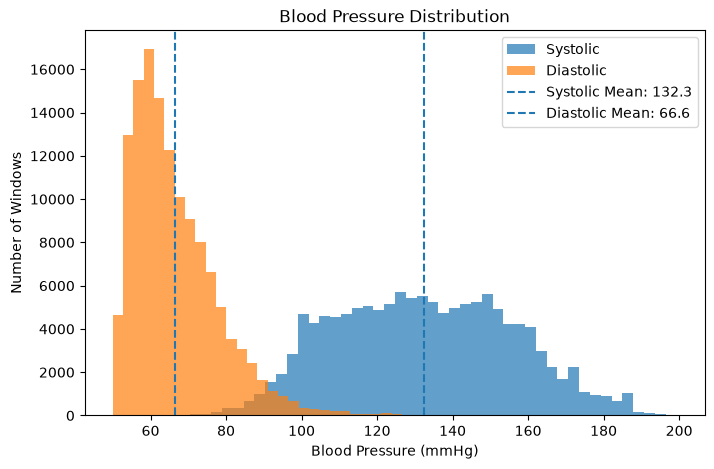

Systolic mean: 132.33707863317204
Systolic standard deviation: 23.423364484861317
Diastolic mean: 66.56738293952566
Diastolic standard deviation: 11.527138391642296
First window mean: 7.105427357601002e-17
First window standard deviation: 1.0

Part 2 Distributions


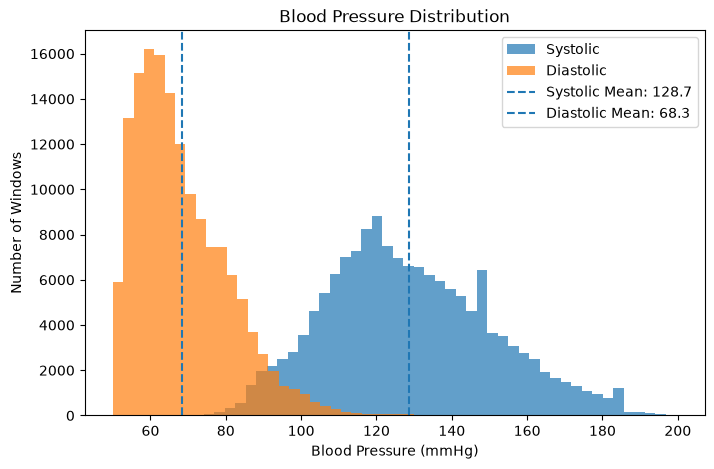

Systolic mean: 128.70162594588388
Systolic standard deviation: 21.97758083603721
Diastolic mean: 68.32893765958498
Diastolic standard deviation: 12.51703534103474
First window mean: 1.3926637620897963e-16
First window standard deviation: 1.0000000000000002

Part 3 Distributions


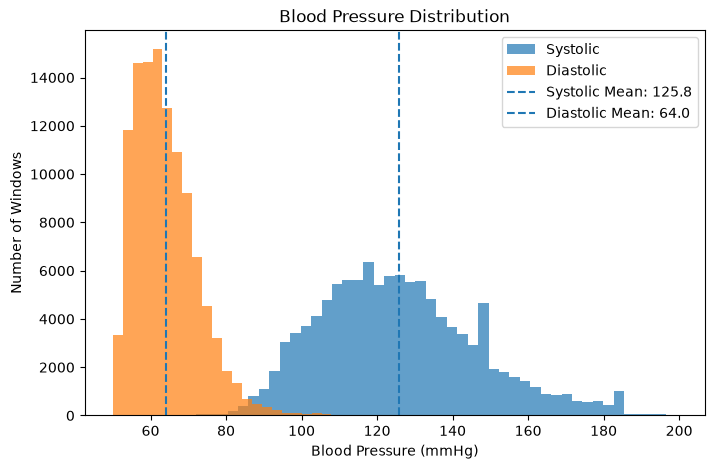

Systolic mean: 125.78021312542182
Systolic standard deviation: 21.07073450017888
Diastolic mean: 63.99876372650296
Diastolic standard deviation: 8.773748137356904
First window mean: -2.1600499167107046e-16
First window standard deviation: 1.0

Part 4 Distributions


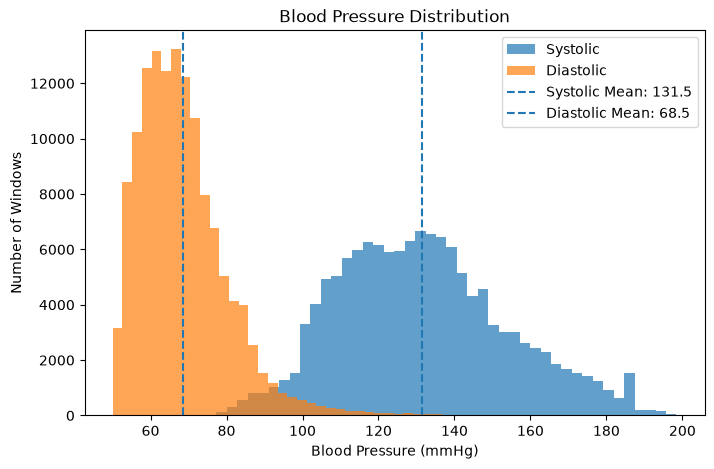

Systolic mean: 131.52031870907024
Systolic standard deviation: 22.293100507476602
Diastolic mean: 68.53440272111057
Diastolic standard deviation: 11.893407639171867
First window mean: 0.0
First window standard deviation: 0.9999999999999998


In [13]:
plot_bp_distribution(1, part1)
plot_bp_distribution(2, part2)
plot_bp_distribution(3, part3)
plot_bp_distribution(4, part4)

## Signal Quality Investigation

PPG and ABP waveforms are visualized to examine the quality of the signals and investigate potentially unusual blood pressure labels. This helps determine whether extreme labels represent valid physiological signals or noisy data.

In [14]:
def qualityInvesting(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    normal_indices = np.where(
        (all_systolic_labels >= 100) &
        (all_systolic_labels <= 140) &
        (all_diastolic_labels >= 60) &
        (all_diastolic_labels <= 90)
    )[0]

    print("\n" + "=" * 60)
    print(f"Part {partNum} Quality Investing")
    print("=" * 60)
    normal_index = normal_indices[0]

    print("Window index:", normal_index)
    print("Systolic:", all_systolic_labels[normal_index])
    print("Diastolic:", all_diastolic_labels[normal_index])

    plt.figure(figsize=(10, 4))
    plt.plot(all_ppg_windows[normal_index])

    plt.title("Normalized PPG - Typical Window")
    plt.xlabel("Sample")
    plt.ylabel("Normalized PPG")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(all_abp_windows[normal_index])

    plt.title("ABP - Typical Window")
    plt.xlabel("Sample")
    plt.ylabel("Blood Pressure (mmHg)")
    plt.show()


Part 1 Quality Investing
Window index: 0
Systolic: 121.84161810748634
Diastolic: 67.18506542667768


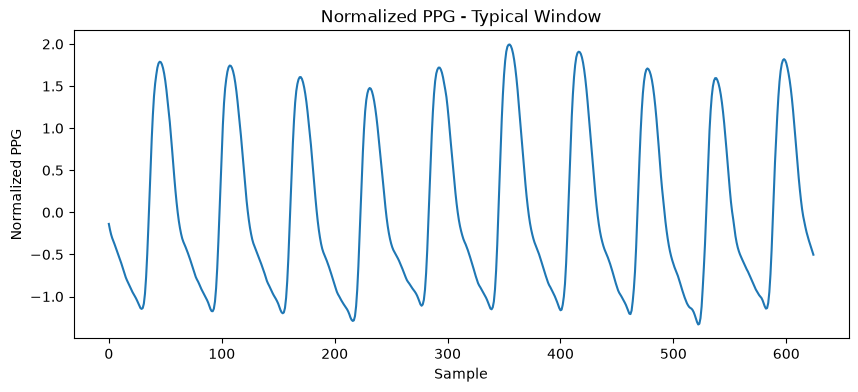

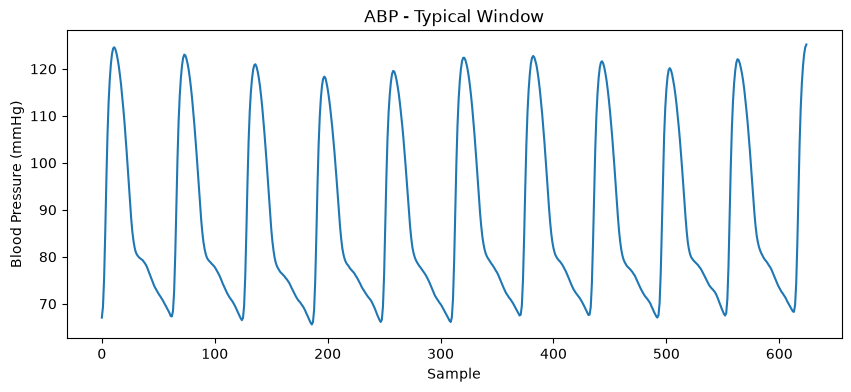


Part 2 Quality Investing
Window index: 0
Systolic: 100.91259404819084
Diastolic: 71.18640355337493


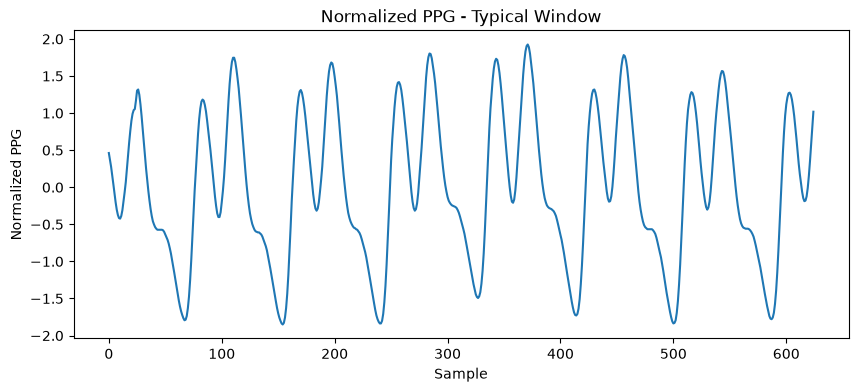

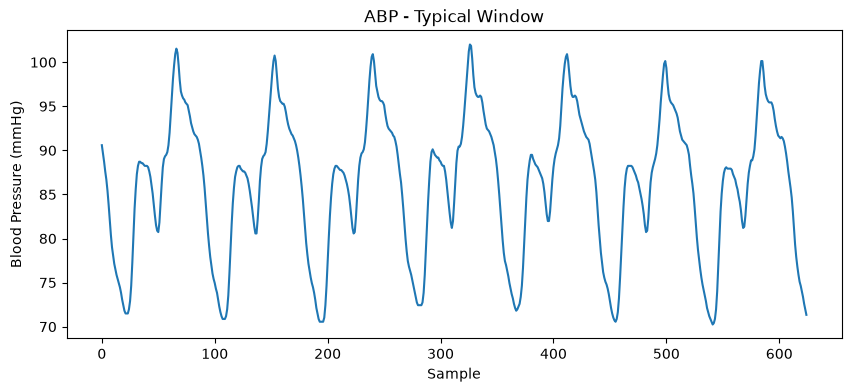


Part 3 Quality Investing
Window index: 0
Systolic: 125.35862148541165
Diastolic: 60.23471984010419


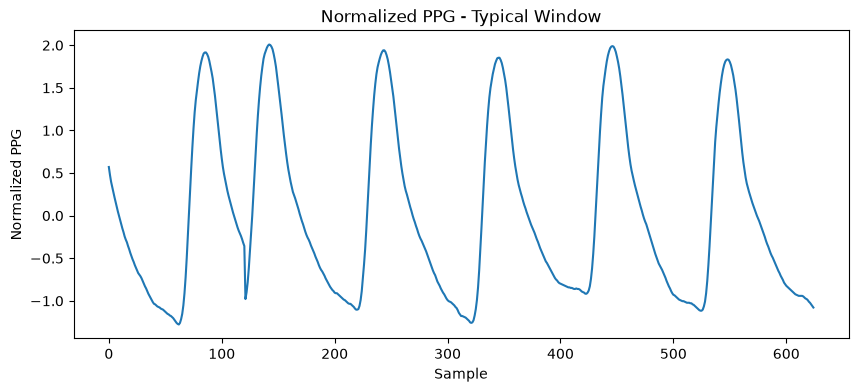

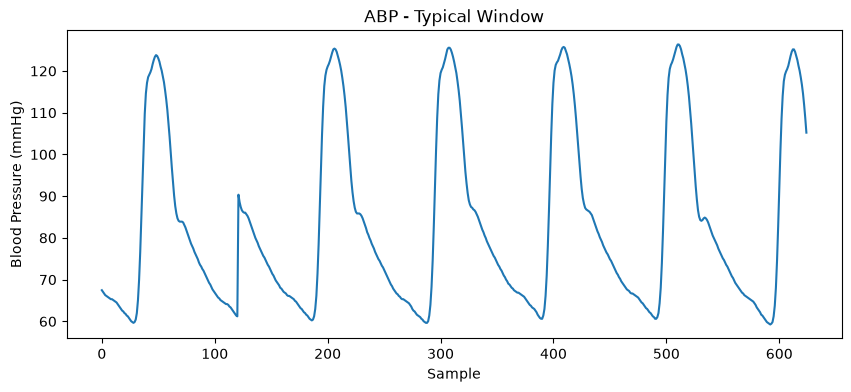


Part 4 Quality Investing
Window index: 0
Systolic: 108.48275558898663
Diastolic: 79.5670458597295


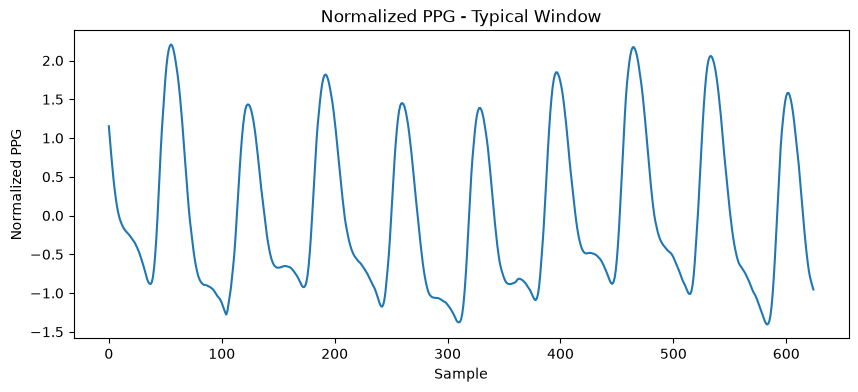

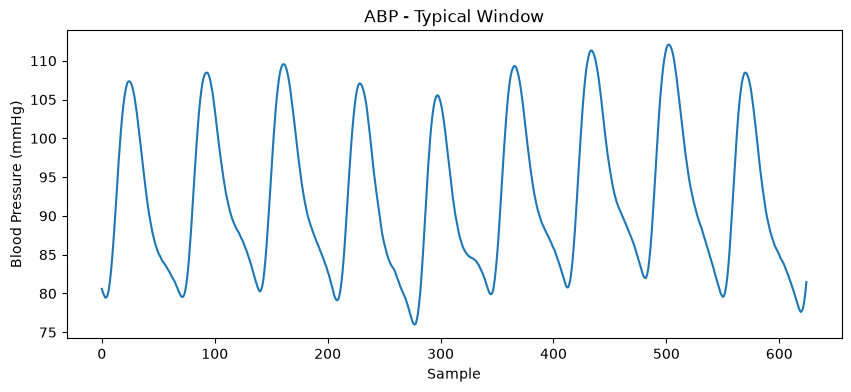

In [15]:
qualityInvesting(1, part1)
qualityInvesting(2, part2)
qualityInvesting(3, part3)
qualityInvesting(4, part4)

In [16]:
# Find a window with an unusually high diastolic label
def extremeBPInvesting(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    extreme_indices = np.where(all_diastolic_labels > 120)[0]

    print("\n" + "=" * 60)
    print(f"Part {partNum} Extreme BP Investing")
    print("=" * 60)
    extreme_index = extreme_indices[0]

    print("Window index:", extreme_index)
    print("Systolic:", all_systolic_labels[extreme_index])
    print("Diastolic:", all_diastolic_labels[extreme_index])

    plt.figure(figsize=(10, 4))
    plt.plot(all_ppg_windows[extreme_index])

    plt.title("Normalized PPG - Extreme BP Window")
    plt.xlabel("Sample")
    plt.ylabel("Normalized PPG")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(all_abp_windows[extreme_index])

    plt.title("ABP - Extreme BP Window")
    plt.xlabel("Sample")
    plt.ylabel("Blood Pressure (mmHg)")
    plt.show()


Part 1 Extreme BP Investing
Window index: 2939
Systolic: 175.63334418767545
Diastolic: 129.71019211991512


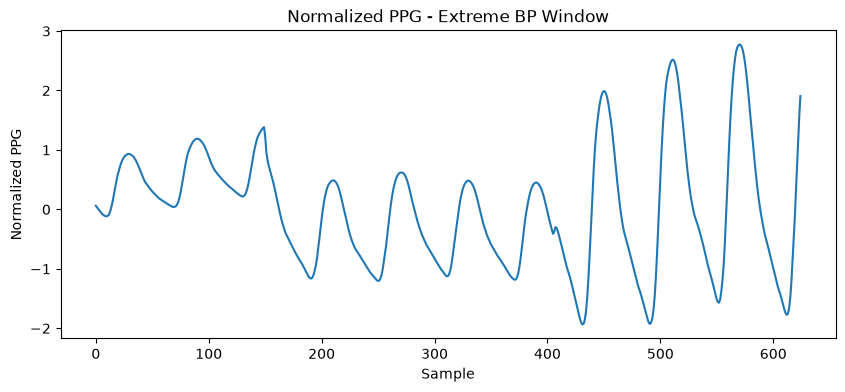

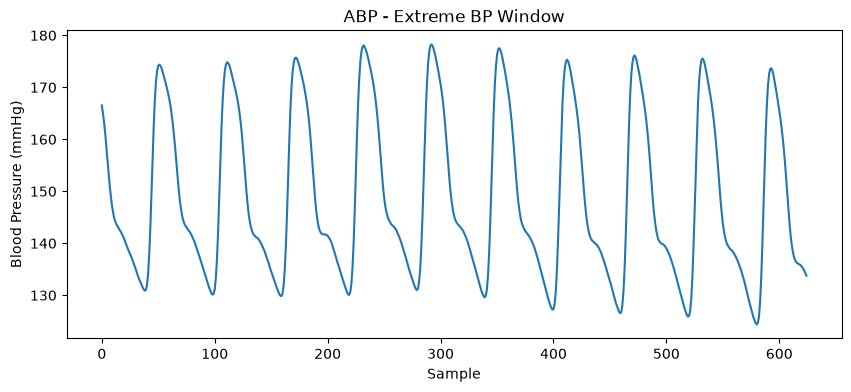


Part 2 Extreme BP Investing
Window index: 2604
Systolic: 144.26580544826143
Diastolic: 122.0417597145944


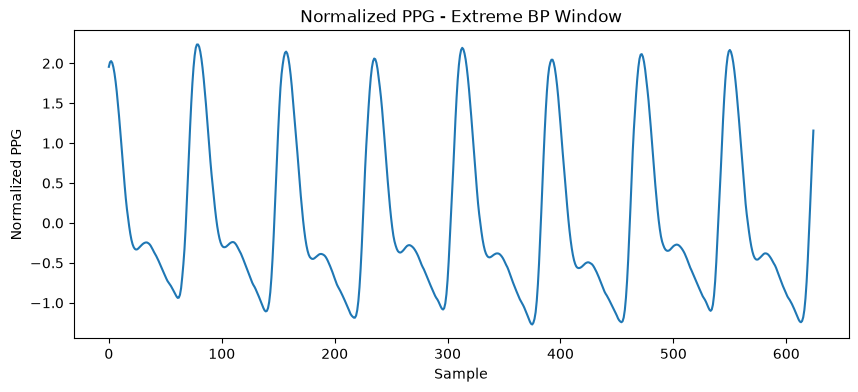

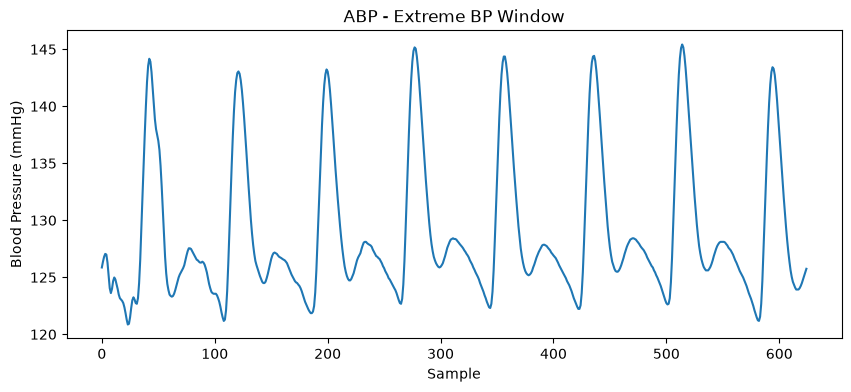


Part 3 Extreme BP Investing
Window index: 12219
Systolic: 141.25673558223957
Diastolic: 124.37626261639517


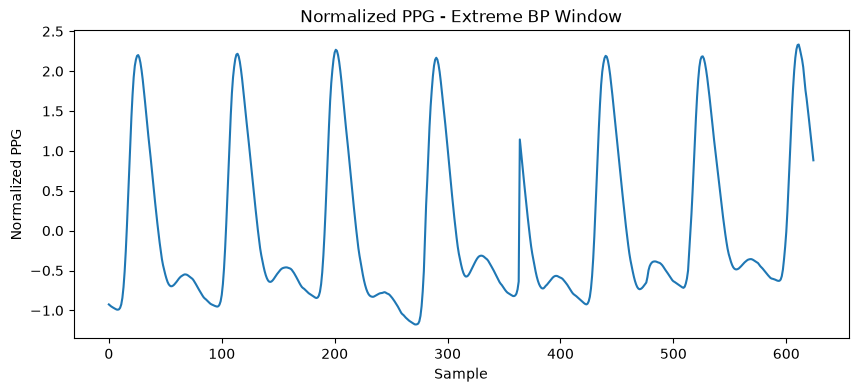

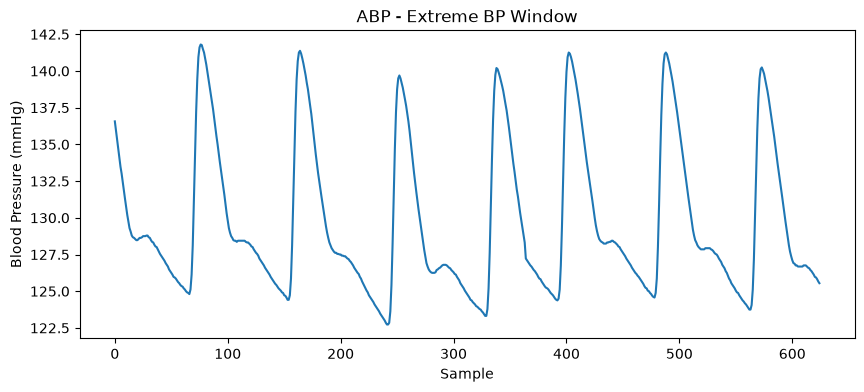


Part 4 Extreme BP Investing
Window index: 953
Systolic: 132.36752257818722
Diastolic: 120.93800217844706


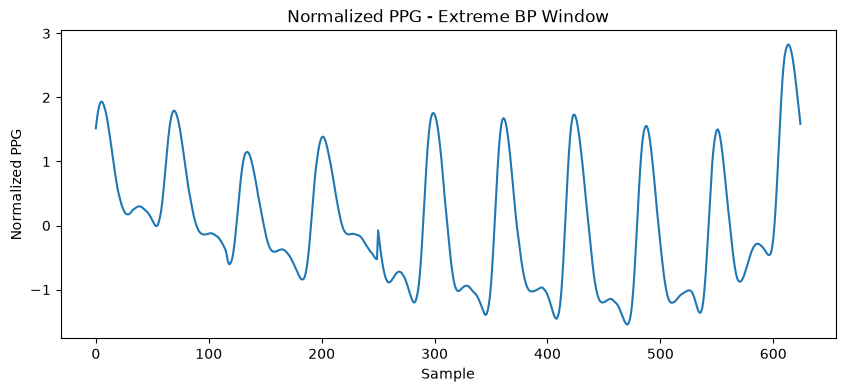

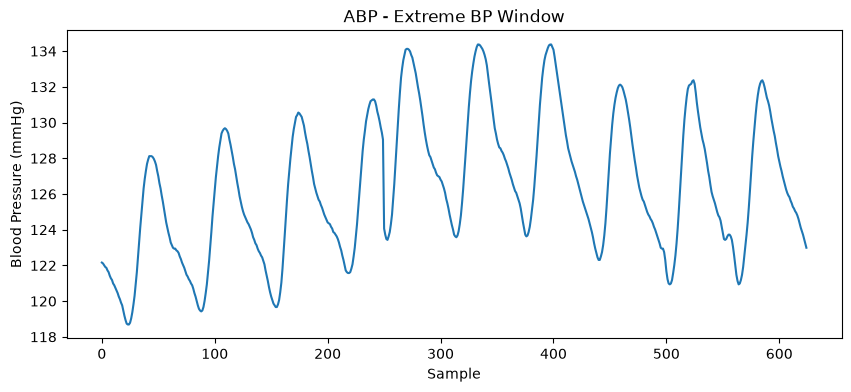

In [17]:
extremeBPInvesting(1, part1)
extremeBPInvesting(2, part2)
extremeBPInvesting(3, part3)
extremeBPInvesting(4, part4)

### Signal Quality Findings

The typical window showed clear repeating PPG and ABP waveforms. An example with an unusually high blood pressure label (approximately 175.94/128.56 mmHg) was also inspected. Although the PPG waveform showed more variation, the ABP signal maintained clear and repeating peaks and valleys.

This suggests that extreme blood pressure labels should not automatically be treated as outliers or removed based only on their blood pressure values. Signal quality should be considered separately when identifying noisy or unusable windows.


## Signal Quality Checks

Additional checks are used to identify potentially noisy or unusable PPG windows. Windows with extremely low variation or unusually large signal changes are flagged for further investigation rather than automatically removed.

In [18]:
def signalQualityCheck(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    ppg_std_values = np.std(all_ppg_windows, axis=1)

    print("\n" + "=" * 60)
    print(f"Part {partNum} Signal Quality Check")
    print("=" * 60)
    ppg_max_changes = np.max(
        np.abs(np.diff(all_ppg_windows, axis=1)),
        axis=1
    )

    print("PPG standard deviation range:")
    print(np.min(ppg_std_values), "-", np.max(ppg_std_values))

    print("\nPPG maximum sample-to-sample change range:")
    print(np.min(ppg_max_changes), "-", np.max(ppg_max_changes))

    print("\nWindows with very large sample-to-sample changes:",
        np.sum(ppg_max_changes > 5))

In [19]:
signalQualityCheck(1, part1)
signalQualityCheck(2, part2)
signalQualityCheck(3, part3)
signalQualityCheck(4, part4)


Part 1 Signal Quality Check
PPG standard deviation range:
0.9999999999999997 - 1.0000000000000002

PPG maximum sample-to-sample change range:
0.11289664252941839 - 5.552345451598399

Windows with very large sample-to-sample changes: 5

Part 2 Signal Quality Check
PPG standard deviation range:
0.9999999999999997 - 1.0000000000000002

PPG maximum sample-to-sample change range:
0.14388445958877594 - 6.126496557671543

Windows with very large sample-to-sample changes: 4

Part 3 Signal Quality Check
PPG standard deviation range:
0.9999999999999997 - 1.0000000000000002

PPG maximum sample-to-sample change range:
0.11399127070882177 - 5.390714470231829

Windows with very large sample-to-sample changes: 3

Part 4 Signal Quality Check
PPG standard deviation range:
0.9999999999999997 - 1.0000000000000002

PPG maximum sample-to-sample change range:
0.13553545936927697 - 9.579362301890274

Windows with very large sample-to-sample changes: 6


### Suspicious PPG Windows

A small number of PPG windows showed unusually large changes between consecutive samples. These windows are inspected visually to determine whether they contain signal artifacts or valid pulse patterns.

In [20]:
def suspiciousPPGWindows(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    ppg_max_changes = np.max(
        np.abs(np.diff(all_ppg_windows, axis=1)),
        axis=1
    )
    print("\n" + "=" * 60)
    print(f"Part {partNum} Suspicious PPG Windows")
    print("=" * 60)
    suspicious_indices = np.where(ppg_max_changes > 5)[0]

    print("Suspicious window indices:", suspicious_indices)
    print("Number of suspicious windows:", len(suspicious_indices))

    for index in suspicious_indices:

        print("\nWindow:", index)
        print("Systolic:", all_systolic_labels[index])
        print("Diastolic:", all_diastolic_labels[index])
        print("Maximum change:", ppg_max_changes[index])

        plt.figure(figsize=(10, 4))
        plt.plot(all_ppg_windows[index])

        plt.title(f"Suspicious PPG Window {index}")
        plt.xlabel("Sample")
        plt.ylabel("Normalized PPG")

        plt.show()


Part 1 Suspicious PPG Windows
Suspicious window indices: [ 42954  44476  48999  74576 122382]
Number of suspicious windows: 5

Window: 42954
Systolic: 145.115833793282
Diastolic: 70.53088656933666
Maximum change: 5.22129026635994


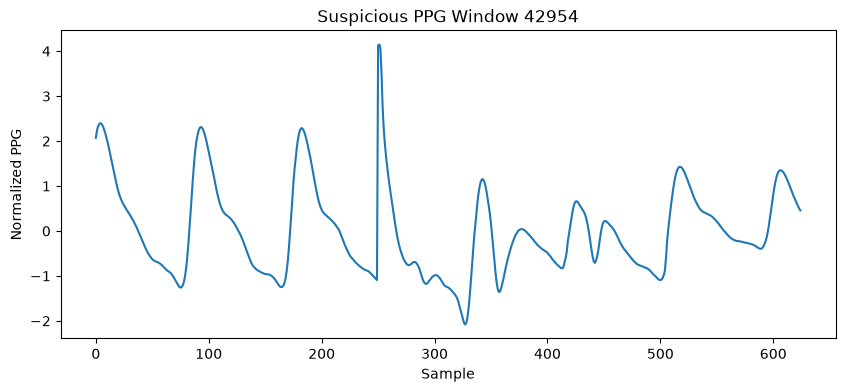


Window: 44476
Systolic: 119.0330821118237
Diastolic: 52.409723884278556
Maximum change: 5.552345451598399


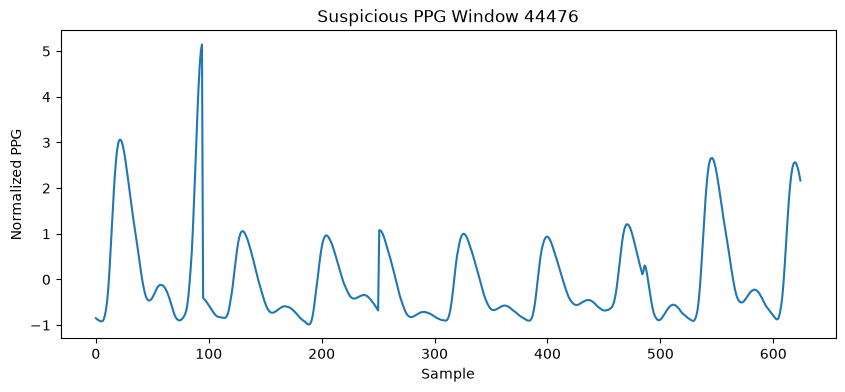


Window: 48999
Systolic: 169.12271104316355
Diastolic: 67.60024031299302
Maximum change: 5.025636257820555


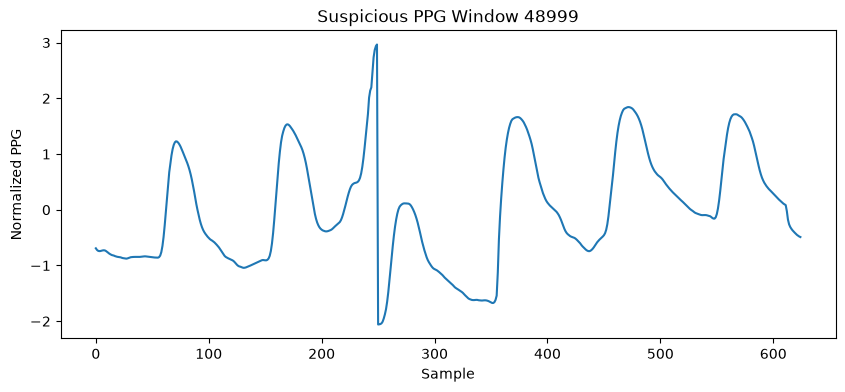


Window: 74576
Systolic: 138.61956792505362
Diastolic: 62.154122686621115
Maximum change: 5.0989262579287375


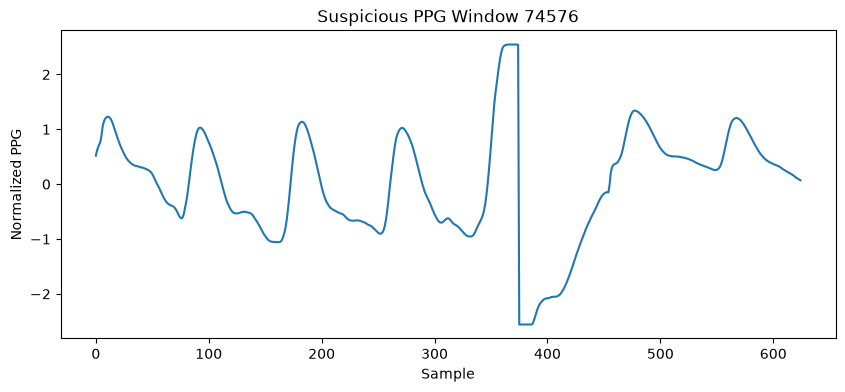


Window: 122382
Systolic: 129.8520512081589
Diastolic: 67.94214904289979
Maximum change: 5.389901704510089


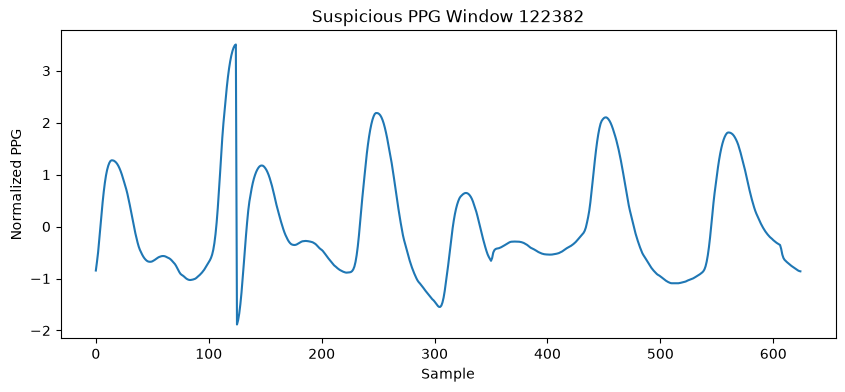


Part 2 Suspicious PPG Windows
Suspicious window indices: [ 13766  83843 100519 139477]
Number of suspicious windows: 4

Window: 13766
Systolic: 137.05615492522966
Diastolic: 106.30399699902704
Maximum change: 5.211504193598951


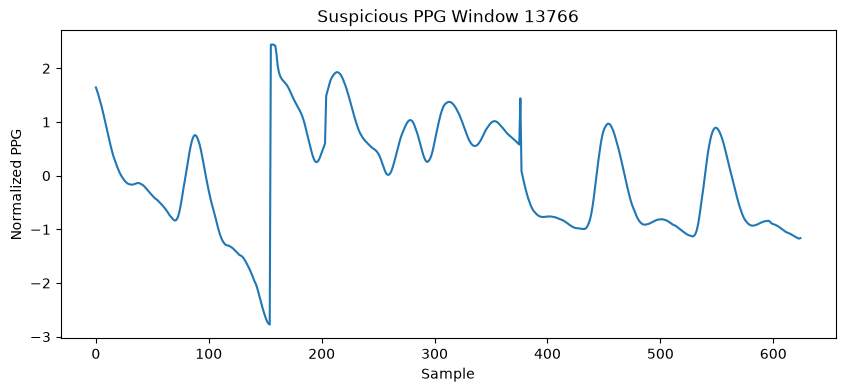


Window: 83843
Systolic: 136.99754217187603
Diastolic: 68.83091002160857
Maximum change: 5.761517923410683


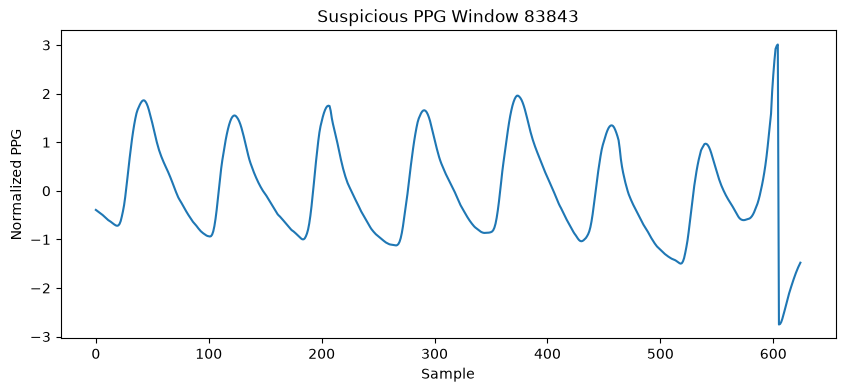


Window: 100519
Systolic: 139.04833053998078
Diastolic: 71.38205435596763
Maximum change: 6.126496557671543


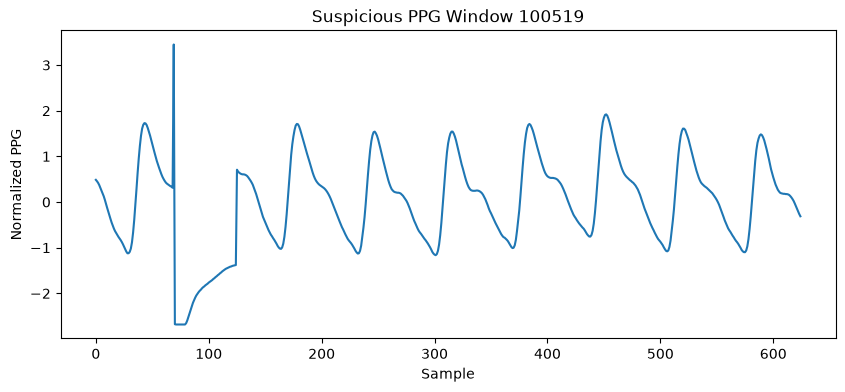


Window: 139477
Systolic: 145.40889841891635
Diastolic: 65.93954076773164
Maximum change: 5.512905144608411


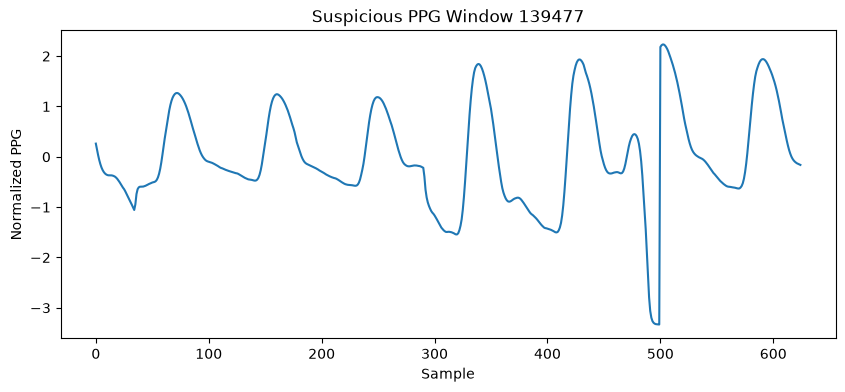


Part 3 Suspicious PPG Windows
Suspicious window indices: [ 1513 23819 38721]
Number of suspicious windows: 3

Window: 1513
Systolic: 103.45508699810104
Diastolic: 51.53197622684239
Maximum change: 5.075509602288072


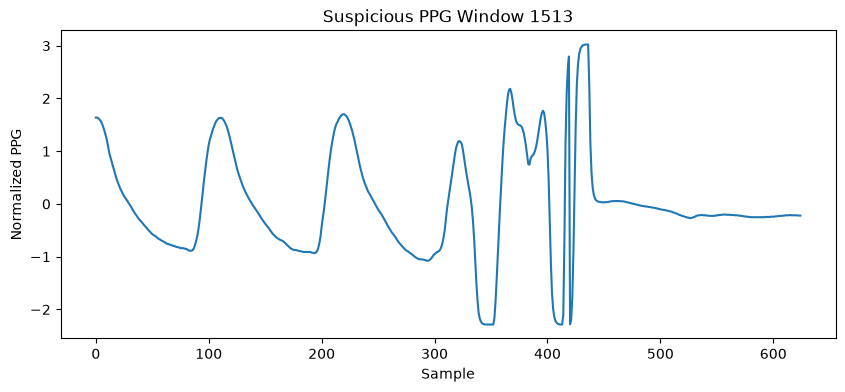


Window: 23819
Systolic: 92.11998065773471
Diastolic: 56.756849164521604
Maximum change: 5.202061772461985


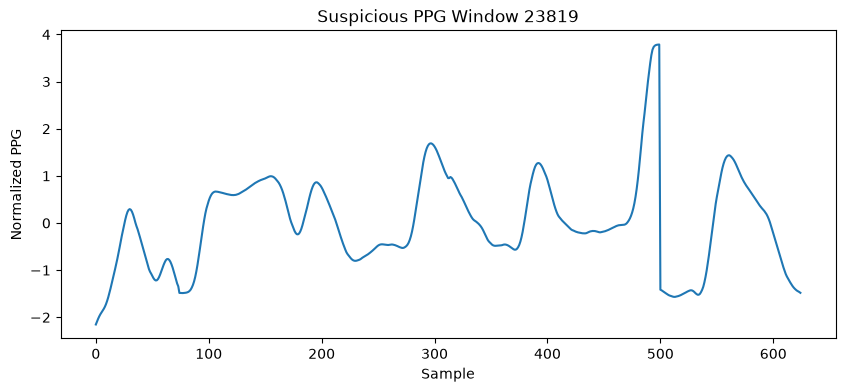


Window: 38721
Systolic: 139.93835874040826
Diastolic: 66.81873464463473
Maximum change: 5.390714470231829


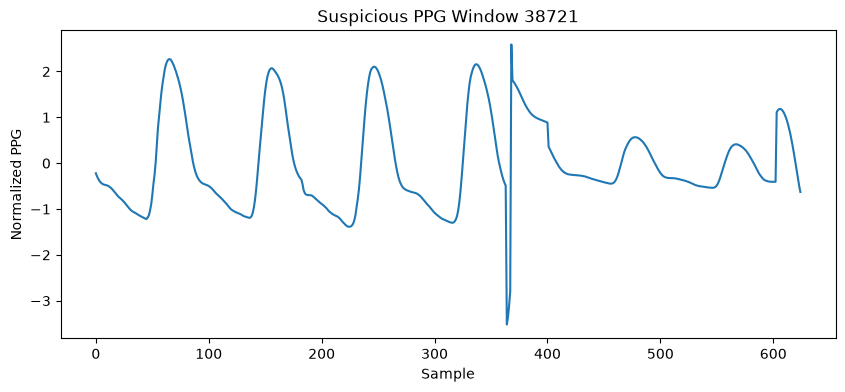


Part 4 Suspicious PPG Windows
Suspicious window indices: [ 25368  50500  77369  79609 104609 107947]
Number of suspicious windows: 6

Window: 25368
Systolic: 143.4551342480206
Diastolic: 101.10729584385517
Maximum change: 9.579362301890274


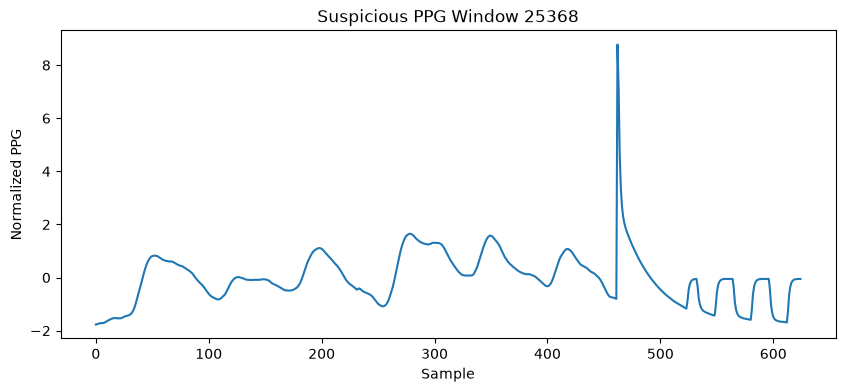


Window: 50500
Systolic: 111.2180254282407
Diastolic: 66.37913770618319
Maximum change: 5.243100579912177


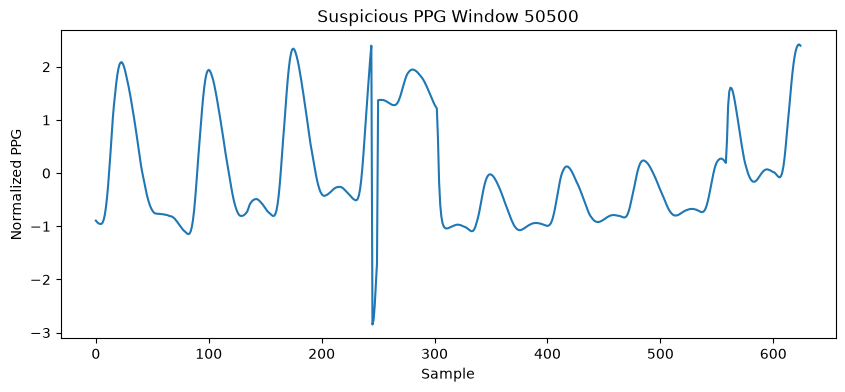


Window: 77369
Systolic: 123.38020739206675
Diastolic: 66.86757874890712
Maximum change: 6.994738747665182


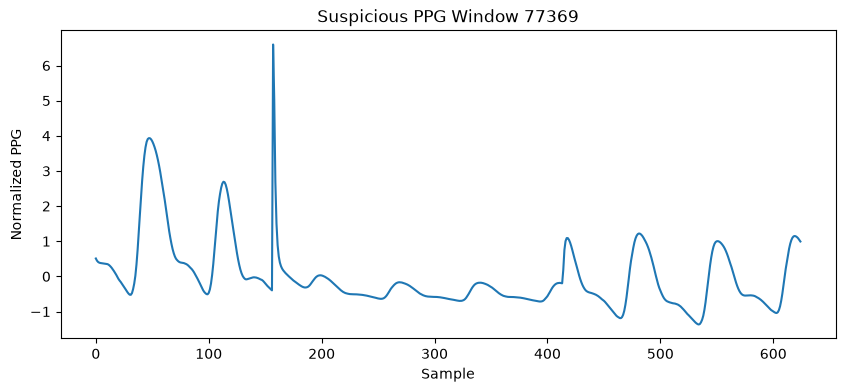


Window: 79609
Systolic: 121.57297553398818
Diastolic: 73.41268872140789
Maximum change: 6.075224926026204


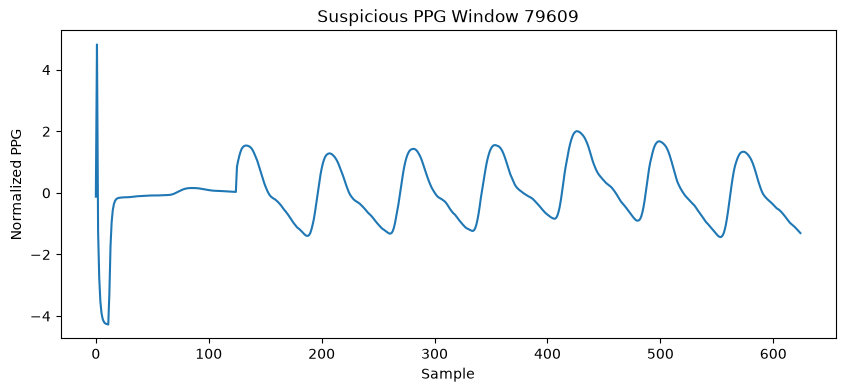


Window: 104609
Systolic: 128.48769784074173
Diastolic: 55.932239851525324
Maximum change: 5.848238076131502


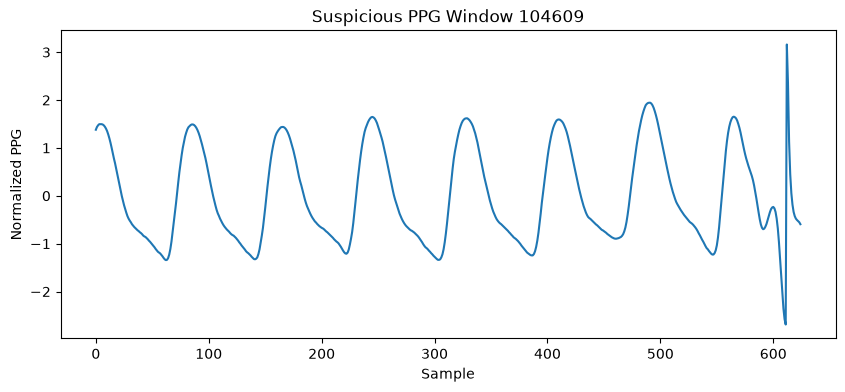


Window: 107947
Systolic: 127.19004752531347
Diastolic: 64.47421763955982
Maximum change: 5.282548396625231


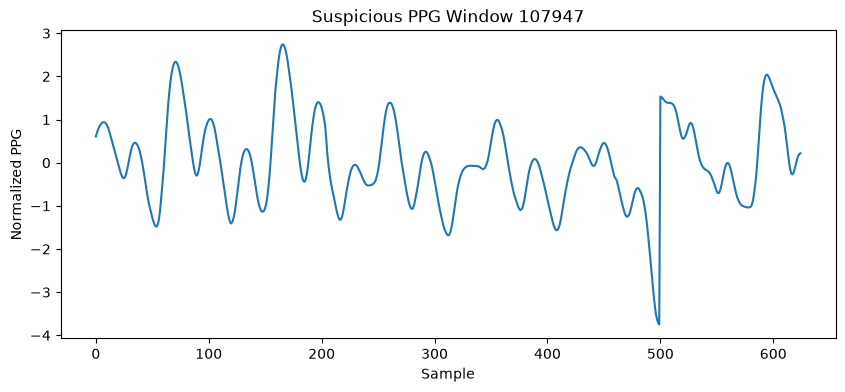

In [21]:
suspiciousPPGWindows(1, part1)
suspiciousPPGWindows(2, part2)
suspiciousPPGWindows(3, part3)
suspiciousPPGWindows(4, part4)

### PPG Signal Change Distribution

The distribution of maximum sample-to-sample changes is examined to understand whether the five flagged windows are isolated extreme cases compared with the rest of the dataset.

In [22]:
def ppgChangeDistribution(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    ppg_max_changes = np.max(
        np.abs(np.diff(all_ppg_windows, axis=1)),
        axis=1
    )
    print("\n" + "=" * 60)
    print(f"Part {partNum} PPG Change Distribution")
    print("=" * 60)
    plt.figure(figsize=(8, 5))

    plt.hist(ppg_max_changes, bins=100)

    plt.xlabel("Maximum Sample-to-Sample Change")
    plt.ylabel("Number of Windows")
    plt.title("Distribution of Maximum PPG Changes")

    plt.show()

    print("95th percentile:", np.percentile(ppg_max_changes, 95))
    print("99th percentile:", np.percentile(ppg_max_changes, 99))
    print("99.9th percentile:", np.percentile(ppg_max_changes, 99.9))
    print("Maximum:", np.max(ppg_max_changes))


Part 1 PPG Change Distribution


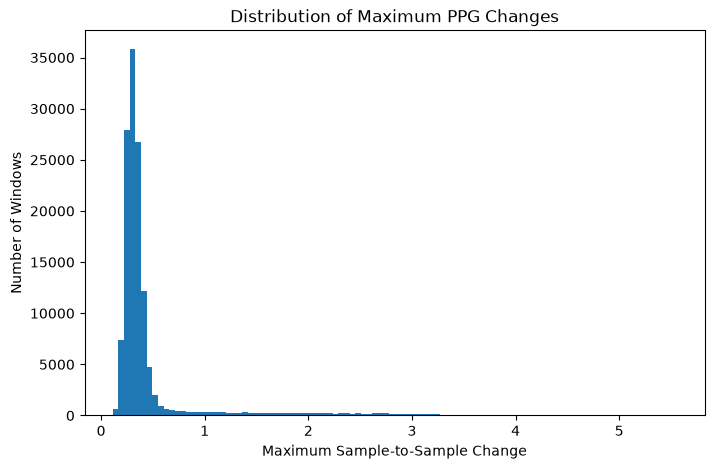

95th percentile: 1.5617252846966863
99th percentile: 2.903155841071698
99.9th percentile: 3.5411052353949914
Maximum: 5.552345451598399

Part 2 PPG Change Distribution


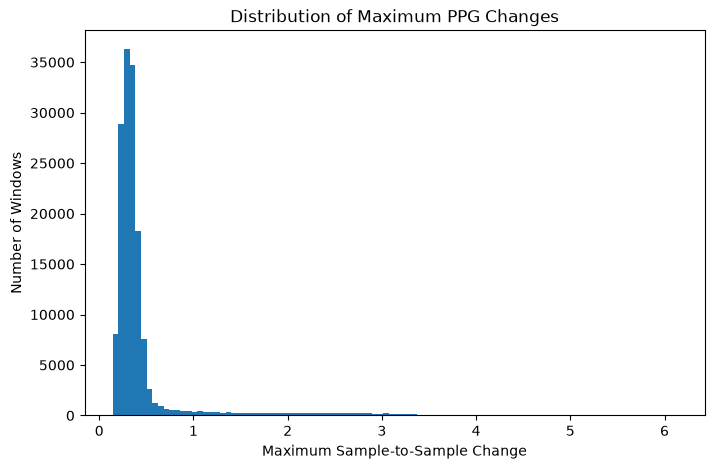

95th percentile: 1.4464873265723173
99th percentile: 2.9392757076622207
99.9th percentile: 3.5993485062618964
Maximum: 6.126496557671543

Part 3 PPG Change Distribution


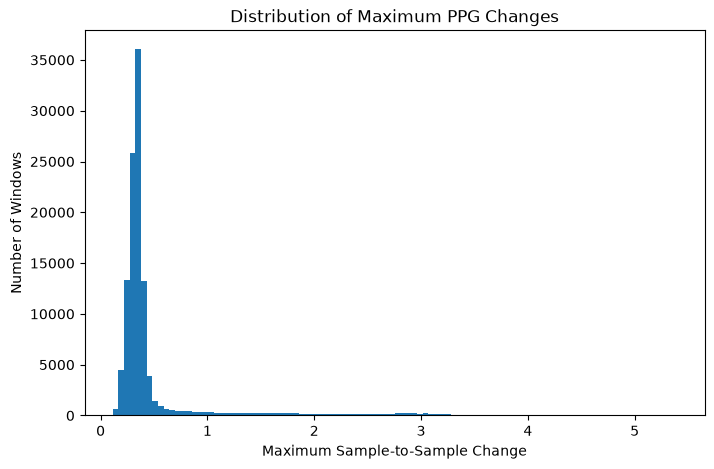

95th percentile: 1.7479131319016339
99th percentile: 3.0321723362093045
99.9th percentile: 3.6186417760982112
Maximum: 5.390714470231829

Part 4 PPG Change Distribution


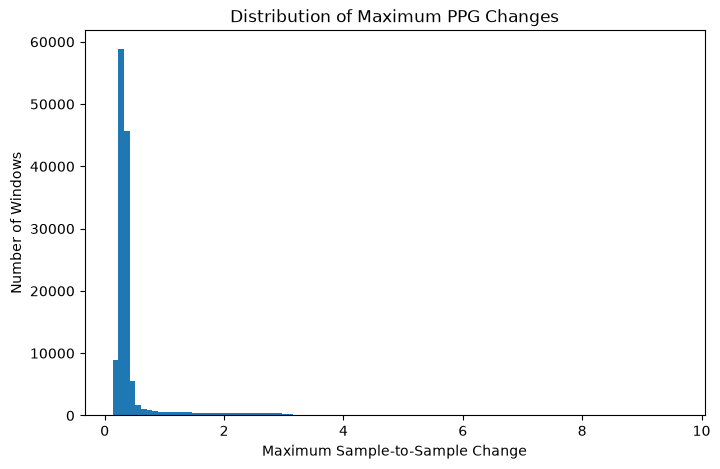

95th percentile: 1.5815978559601302
99th percentile: 2.8366666253680917
99.9th percentile: 3.585209777924626
Maximum: 9.579362301890274


In [23]:
ppgChangeDistribution(1, part1)
ppgChangeDistribution(2, part2)
ppgChangeDistribution(3, part3)
ppgChangeDistribution(4, part4)

### Signal Quality Findings

Most PPG windows had relatively small sample-to-sample changes. The 95th percentile was approximately 1.56, the 99th percentile was 2.90, and the 99.9th percentile was 3.54. Only five windows had a maximum change greater than 5.

Visual inspection of these five windows showed abrupt jumps or spikes that differed from the typical repeating PPG waveform. These five windows were treated as likely signal artifacts and removed. Blood pressure values were not removed simply because they were unusually high or low.

## Remove Noisy PPG Windows

The five PPG windows identified as likely signal artifacts are removed while keeping the PPG, ABP, systolic, and diastolic data aligned.

In [24]:
def removeNoisyWindows(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    ppg_max_changes = np.max(
        np.abs(np.diff(all_ppg_windows, axis=1)),
        axis=1
    )
    print("\n" + "=" * 60)
    print(f"Part {partNum} Remove Noisy Windows")
    print("=" * 60)
    noise_mask = ppg_max_changes <= 5

    clean_ppg_windows = all_ppg_windows[noise_mask]
    clean_abp_windows = all_abp_windows[noise_mask]
    clean_systolic_labels = all_systolic_labels[noise_mask]
    clean_diastolic_labels = all_diastolic_labels[noise_mask]

    print("Examples before filtering:", len(all_ppg_windows))
    print("Noisy windows removed:", np.sum(~noise_mask))
    print("Examples after filtering:", len(clean_ppg_windows))

In [25]:
removeNoisyWindows(1, part1)
removeNoisyWindows(2, part2)
removeNoisyWindows(3, part3)
removeNoisyWindows(4, part4)


Part 1 Remove Noisy Windows
Examples before filtering: 131162
Noisy windows removed: 5
Examples after filtering: 131157

Part 2 Remove Noisy Windows
Examples before filtering: 151304
Noisy windows removed: 4
Examples after filtering: 151300

Part 3 Remove Noisy Windows
Examples before filtering: 112449
Noisy windows removed: 3
Examples after filtering: 112446

Part 4 Remove Noisy Windows
Examples before filtering: 133910
Noisy windows removed: 6
Examples after filtering: 133904


## Final Cleaned Dataset

In [26]:
def cleanDataset(partNum, part):
    all_ppg_windows, all_abp_windows, all_systolic_labels, all_diastolic_labels = part
    ppg_max_changes = np.max(
        np.abs(np.diff(all_ppg_windows, axis=1)),
        axis=1
    )
    noise_mask = ppg_max_changes <= 5

    clean_ppg_windows = all_ppg_windows[noise_mask]
    clean_abp_windows = all_abp_windows[noise_mask]
    clean_systolic_labels = all_systolic_labels[noise_mask]
    clean_diastolic_labels = all_diastolic_labels[noise_mask]

    
    print("\n" + "=" * 60)
    print(f"Part {partNum} Final Cleaned Dataset")
    print("=" * 60)

    print("PPG windows:", clean_ppg_windows.shape)
    print("ABP windows:", clean_abp_windows.shape)
    print("Systolic labels:", clean_systolic_labels.shape)
    print("Diastolic labels:", clean_diastolic_labels.shape)

    print("\n--- Final Blood Pressure Statistics ---")

    print("Mean systolic:", np.mean(clean_systolic_labels))
    print("Systolic standard deviation:", np.std(clean_systolic_labels))
    print("Minimum systolic:", np.min(clean_systolic_labels))
    print("Maximum systolic:", np.max(clean_systolic_labels))

    print("\nMean diastolic:", np.mean(clean_diastolic_labels))
    print("Diastolic standard deviation:", np.std(clean_diastolic_labels))
    print("Minimum diastolic:", np.min(clean_diastolic_labels))
    print("Maximum diastolic:", np.max(clean_diastolic_labels))

    print("\n--- Normalization Check ---")

    print("First PPG window mean:", np.mean(clean_ppg_windows[0]))
    print("First PPG window standard deviation:", np.std(clean_ppg_windows[0]))
    return clean_ppg_windows, clean_abp_windows, clean_systolic_labels, clean_diastolic_labels

In [27]:
cleanDataset(1, part1)
cleanDataset(2, part2)
cleanDataset(3, part3)
cleanDataset(4, part4)


Part 1 Final Cleaned Dataset
PPG windows: (131157, 625)
ABP windows: (131157, 625)
Systolic labels: (131157,)
Diastolic labels: (131157,)

--- Final Blood Pressure Statistics ---
Mean systolic: 132.33677321407194
Systolic standard deviation: 23.423527910709925
Minimum systolic: 56.00459524884093
Maximum systolic: 199.28375075464066

Mean diastolic: 66.56747595623237
Diastolic standard deviation: 11.527279207316898
Minimum diastolic: 50.0
Maximum diastolic: 186.78003719970616

--- Normalization Check ---
First PPG window mean: 7.105427357601002e-17
First PPG window standard deviation: 1.0

Part 2 Final Cleaned Dataset
PPG windows: (151300, 625)
ABP windows: (151300, 625)
Systolic labels: (151300,)
Diastolic labels: (151300,)

--- Final Blood Pressure Statistics ---
Mean systolic: 128.70133708651662
Systolic standard deviation: 21.977792436216365
Minimum systolic: 60.2592216220071
Maximum systolic: 199.63542796185476

Mean diastolic: 68.32867896327629
Diastolic standard deviation: 12.51

(array([[ 1.15255599,  0.97460496,  0.80178713, ..., -0.85281527,
         -0.90756944, -0.95376826],
        [-0.88090166, -0.90374303, -0.91842677, ..., -0.71285442,
         -0.73080121, -0.75364259],
        [-0.77865792, -0.79658943, -0.81941135, ..., -1.02643879,
         -1.04763058, -1.06882237],
        ...,
        [ 1.59454835,  1.55770177,  1.50803898, ...,  0.54842581,
          0.55162987,  0.55002784],
        [ 0.54242588,  0.53779323,  0.53316058, ...,  0.03167621,
         -0.03318089, -0.09108902],
        [-0.38028592, -0.43146352, -0.48099024, ...,  0.73241425,
          0.83972213,  0.93382289]], shape=(133904, 625)),
 array([[ 80.59277205,  80.10433101,  79.76242228, ...,  78.8832284 ,
          80.0066428 ,  81.47196593],
        [ 83.37688599,  85.47718248,  87.87054359, ...,  93.87836841,
          96.0763531 ,  98.03011727],
        [ 99.73966092, 101.25382816, 102.42608666, ...,  96.22288542,
          96.0763531 ,  95.73444437],
        ...,
        [ 60.90

## Milestone 1 Preprocessing Summary

Part 1 of the Cuff-less Blood Pressure dataset contained 3,000 physiological signal records. The PPG and ABP signals were extracted and divided into non-overlapping 5-second windows containing 625 samples each.

The data was checked for missing, infinite, and invalid values, and no invalid records were found. Systolic and diastolic blood pressure labels were generated using peaks and valleys from the ABP signal. One window was skipped because valid peaks or valleys could not be detected.

Each PPG window was normalized using z-score normalization. The normalization check produced a mean approximately equal to 0 and a standard deviation of 1.

Blood pressure ranges and distributions were also investigated. The cleaned dataset had a mean systolic pressure of approximately 130.54 mmHg with a standard deviation of 22.97 mmHg, and a mean diastolic pressure of approximately 67.22 mmHg with a standard deviation of 11.60 mmHg. Extreme blood pressure values were investigated but were not automatically removed based only on their BP values.

Signal quality was evaluated using the maximum sample-to-sample change in each normalized PPG window. Five windows showed unusually large abrupt changes and visual inspection showed spikes or discontinuities compared with typical PPG waveforms. These five windows were removed as likely signal artifacts.

After preprocessing and signal-quality filtering, the final Part 1 dataset contains 131,157 normalized PPG windows with matching ABP signals and systolic and diastolic labels. The cleaned data is ready for feature engineering and model development.